In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

df = pd.read_csv("../data/processed/clinical_clean.csv")

COLORS = {
    "primary":   "#2E4057",
    "secondary": "#048A81",
    "accent":    "#54C6EB",
    "warm":      "#E76F51",
    "gray":      "#6C757D",
    "light":     "#F4F1DE",
}

SUBTYPE_COLORS = {
    "LumA":        "#048A81",
    "LumB":        "#54C6EB",
    "Her2":        "#E76F51",
    "Basal":       "#2E4057",
    "claudin-low": "#F4A261",
    "Normal":      "#6C757D",
}

npi_colors = {
    "Excellent": COLORS["secondary"],
    "Good":      COLORS["accent"],
    "Moderate":  COLORS["warm"],
    "Poor":      COLORS["primary"],
}

feature_labels = {
    "age":         "Age",
    "grade":       "Grade",
    "tumor_size":  "Tumor size",
    "lymph_nodes": "Lymph nodes",
    "chemo_bin":   "Chemotherapy",
    "hormone_bin": "Hormone therapy"
}

# ── NPI risk groups ────────────────────────────────────────────────────────
def npi_group(score):
    if score < 2.4:
        return "Excellent"
    elif score < 3.4:
        return "Good"
    elif score < 5.4:
        return "Moderate"
    else:
        return "Poor"



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

print(f"Shape: {df.shape}")
print(f"\nSubtype counts:\n{df['subtype'].value_counts()}")

Shape: (496, 17)

Subtype counts:
subtype
LumA           164
LumB           124
claudin-low     90
Normal          49
Her2            36
Basal           33
Name: count, dtype: int64


## Subtype Deep-Dive Analysis

Molecular subtypes of breast cancer have distinct biology, treatment response, 
and prognosis. In notebooks 01 and 02 we saw that subtype is one of the strongest 
prognostic factors (log-rank p < 1e-08 for OS, p = 2.32e-05 for RFS).

Here we go deeper — asking whether the **prognostic factors identified in the 
full cohort hold within each subtype**, or whether subtype modifies the effect 
of clinical variables like grade, lymph nodes, and treatment.

**Subtypes analyzed:**
- **LumA** (n=164) — Luminal A: ER+/PR+, HER2-, low grade. Best prognosis.
- **LumB** (n=124) — Luminal B: ER+, HER2- or HER2+, higher grade. Intermediate prognosis.
- **Her2** (n=36) — HER2-enriched: HER2+, ER-. Aggressive, but targeted therapies available.
- **Basal** (n=33) — Basal-like / triple negative: ER-, PR-, HER2-. Worst prognosis, no targeted therapy.
- **claudin-low** (n=90) — Stem cell-like, immune infiltrated. Intermediate-poor prognosis.
- **Normal** (n=49) — Normal-like: resembles normal breast tissue. Favorable prognosis.

> Note: Her2 and Basal have small sample sizes (n=36, n=33) — results for 
> these subtypes should be interpreted with caution.

In [2]:
CUTOFF = 60  # 5 years

summary = []
for subtype in df["subtype"].dropna().unique():
    subset = df[df["subtype"] == subtype]
    summary.append({
        "Subtype":        subtype,
        "n":              len(subset),
        "OS events":      subset["os_event"].sum(),
        "OS event rate":  f"{subset['os_event'].mean():.1%}",
        "Median OS (mo)": f"{subset['os_months'].median():.1f}",
        "5yr mortality":  f"{((subset['os_months'] <= CUTOFF) & (subset['os_event'] == 1)).mean():.1%}",
    })

summary_df = pd.DataFrame(summary).set_index("Subtype")
summary_df = summary_df.loc[["LumA", "LumB", "Her2", "Basal", "claudin-low", "Normal"]]
print(summary_df.to_string())

               n  OS events OS event rate Median OS (mo) 5yr mortality
Subtype                                                               
LumA         164         48         29.3%          101.5         12.8%
LumB         124         73         58.9%           94.5         24.2%
Her2          36         25         69.4%           44.5         47.2%
Basal         33         16         48.5%           75.4         30.3%
claudin-low   90         28         31.1%           93.1         14.4%
Normal        49         18         36.7%          110.1         20.4%


### Survival Summary by Subtype

Key observations from observed data (no modeling):

- **HER2-enriched has the worst short-term prognosis** — 47.2% 5-year mortality 
  and median OS of only 44.5 months, reflecting its aggressive biology
- **LumA has the best overall prognosis** — 29.3% overall mortality and 12.8% 
  5-year mortality, consistent with its low-grade, hormone-driven biology
- **Basal (triple-negative) shows intermediate overall mortality (48.5%)** but 
  lower 5-year mortality (30.3%) than HER2 — suggesting deaths occur later, 
  possibly after initial response to chemotherapy
- **Normal-like subtype has the longest median OS (110.1 months)** despite 
  intermediate event rate — indicating late recurrences in some patients

In [5]:
df["npi_group"] = df["npi"].apply(npi_group)

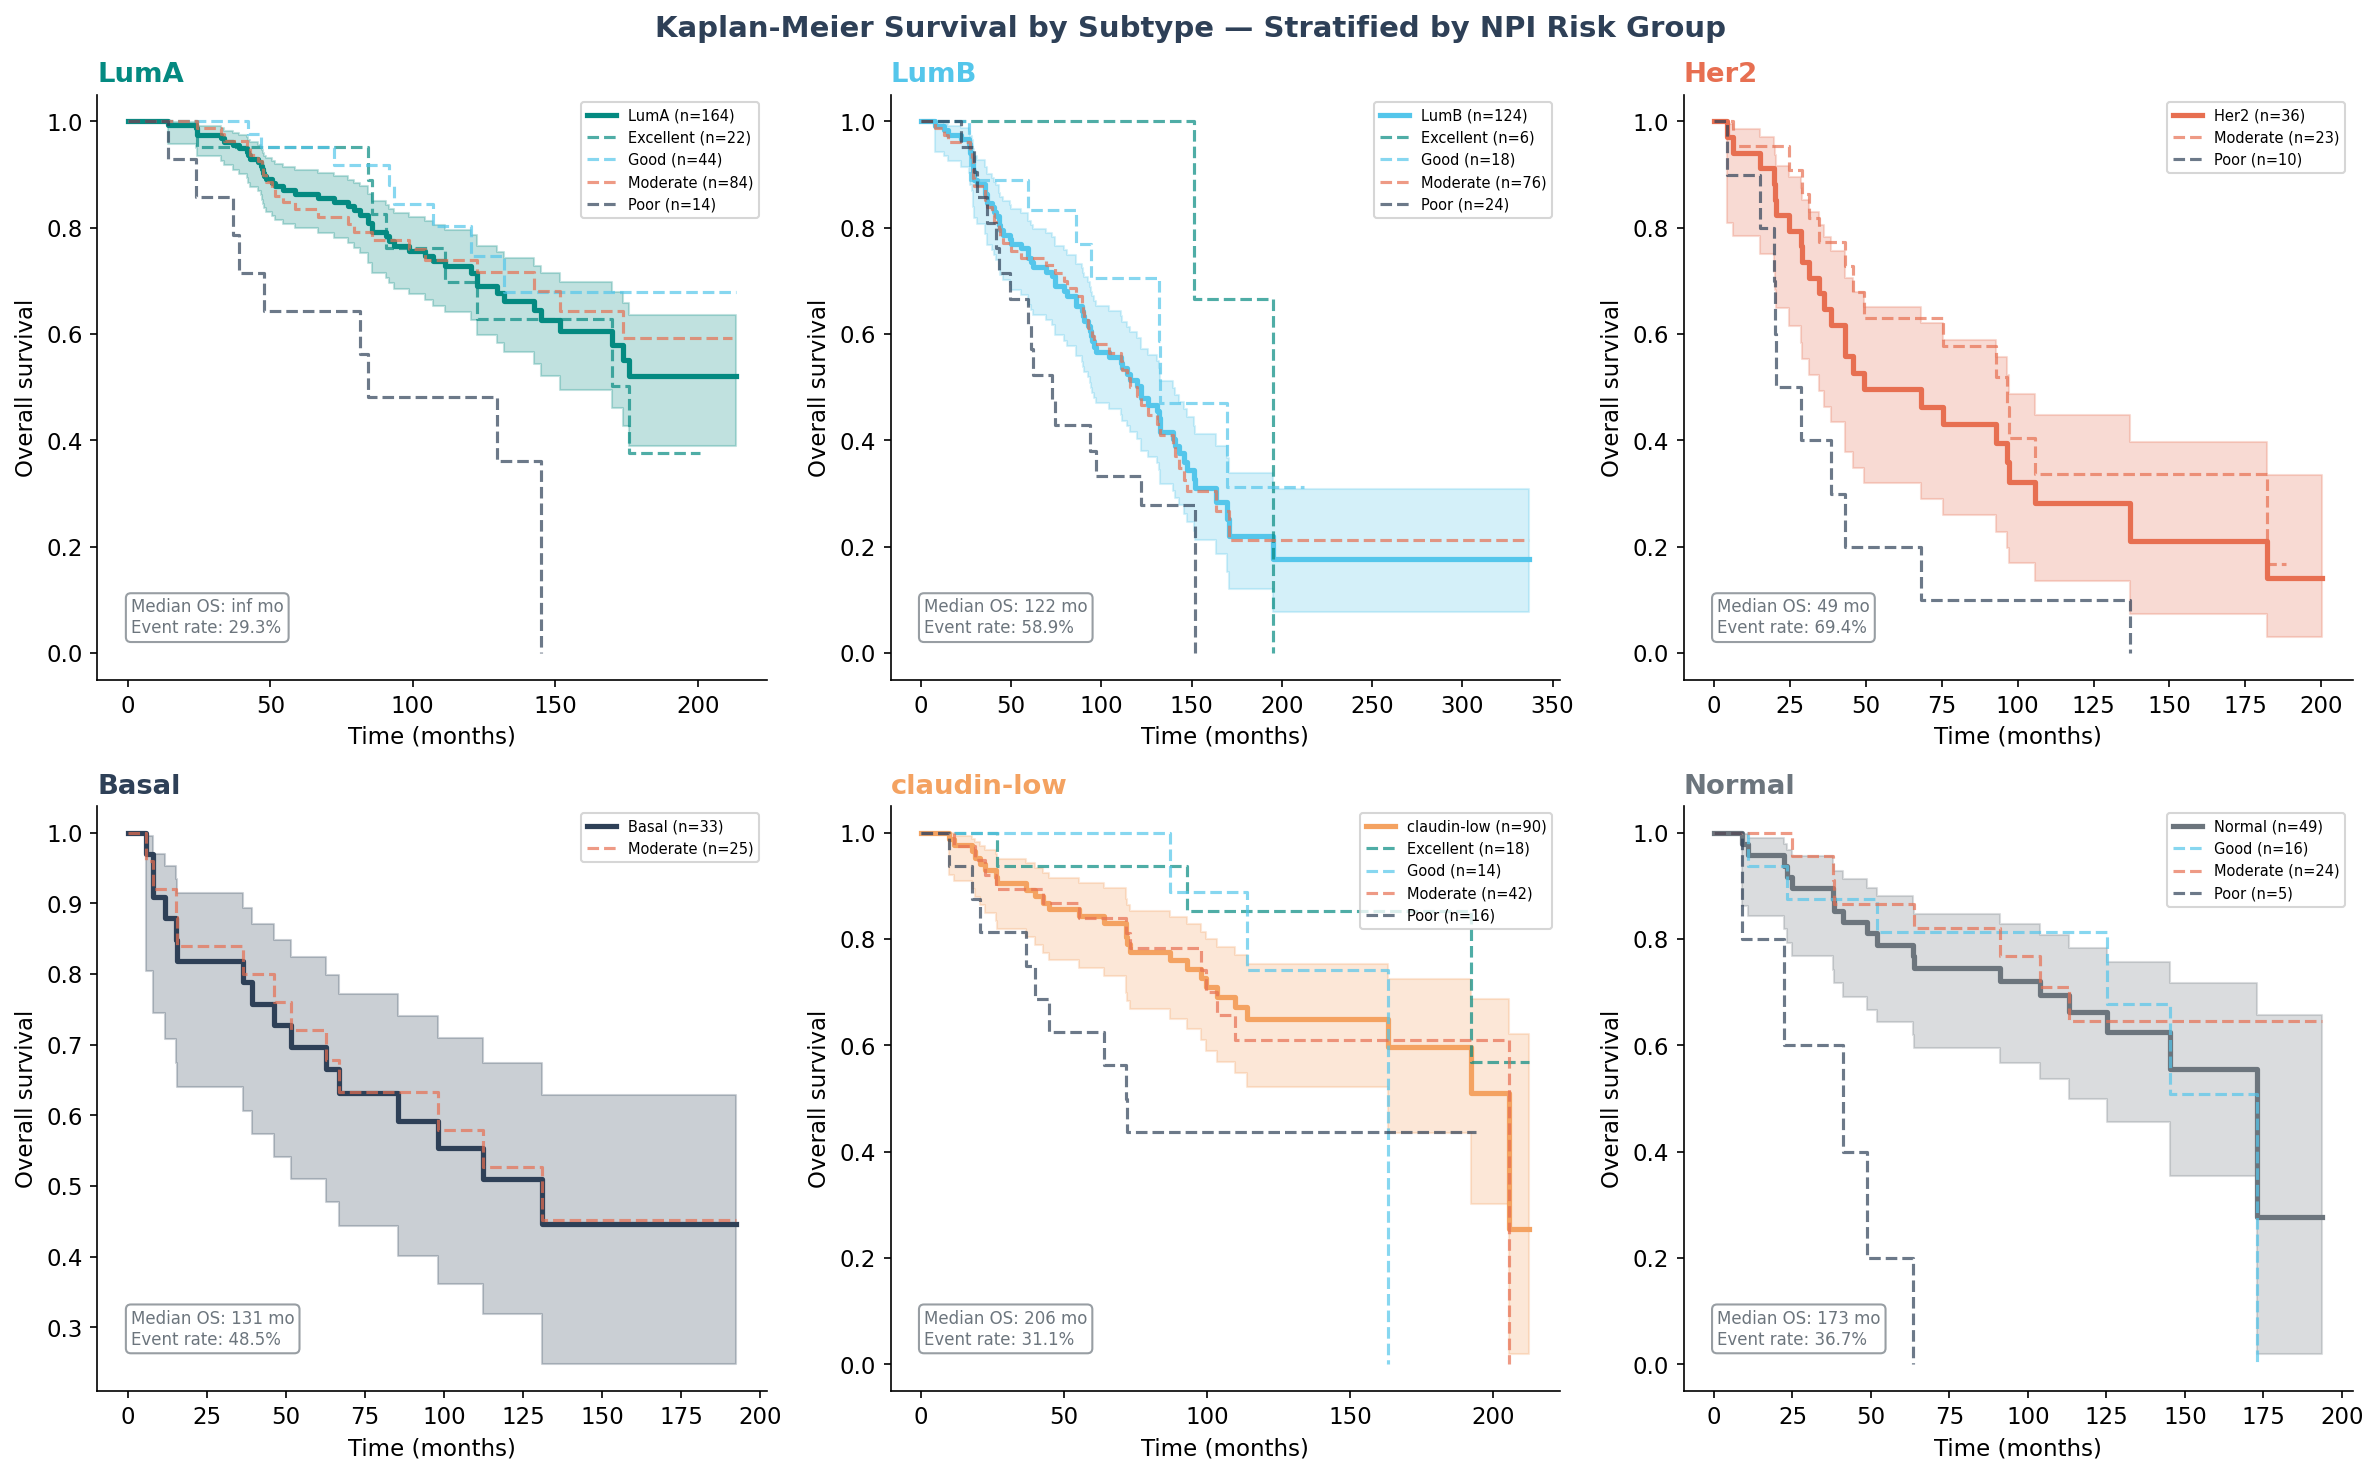

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor("white")
axes = axes.flatten()

subtypes = ["LumA", "LumB", "Her2", "Basal", "claudin-low", "Normal"]

for i, subtype in enumerate(subtypes):
    ax = axes[i]
    subset = df[df["subtype"] == subtype]
    color  = SUBTYPE_COLORS[subtype]

    # Overall KM for this subtype
    kmf = KaplanMeierFitter()
    kmf.fit(subset["os_months"], subset["os_event"],
            label=f"{subtype} (n={len(subset)})")
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color, lw=2.5)

    # Stratify by NPI group within subtype
    for npi_g, npi_c in npi_colors.items():
        mask = subset["npi_group"] == npi_g
        if mask.sum() < 5:
            continue
        kmf2 = KaplanMeierFitter()
        kmf2.fit(subset.loc[mask, "os_months"], subset.loc[mask, "os_event"],
                 label=f"{npi_g} (n={mask.sum()})")
        kmf2.plot_survival_function(ax=ax, ci_show=False, color=npi_c,
                                    lw=1.5, ls="--", alpha=0.7)

    median_os = kmf.median_survival_time_
    event_rate = subset["os_event"].mean()
    ax.text(0.05, 0.08,
            f"Median OS: {median_os:.0f} mo\nEvent rate: {event_rate:.1%}",
            transform=ax.transAxes, fontsize=8, color=COLORS["gray"],
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))

    ax.set_xlabel("Time (months)")
    ax.set_ylabel("Overall survival")
    ax.set_title(f"{subtype}", fontweight="bold", loc="left", color=color)
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("Kaplan-Meier Survival by Subtype — Stratified by NPI Risk Group",
             fontsize=14, fontweight="bold", color=COLORS["primary"])

plt.tight_layout()
plt.savefig("../notebooks/figures/fig8_subtype_km.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings — KM by Subtype Stratified by NPI Group

- **LumA (Median OS: inf)** — the curve never reaches 50% survival within 
  follow-up, confirming its excellent prognosis. NPI Poor group (n=14) 
  drops sharply, showing that even within the best subtype, high NPI 
  identifies a high-risk subset
- **LumB (Median OS: 122 mo)** — NPI separates well within LumB, with Poor 
  group (n=24) having dramatically worse survival — NPI remains informative 
  within this intermediate-risk subtype
- **HER2 (Median OS: 49 mo)** — only Moderate and Poor NPI groups present 
  (n=23, n=10) — too few patients for reliable stratification, but the 
  overall curve confirms aggressive biology
- **Basal (Median OS: 131 mo)** — surprisingly long median OS despite 48.5% 
  event rate; only Moderate NPI group has enough patients (n=25). The wide 
  confidence intervals reflect small sample size (n=33 total)
- **claudin-low (Median OS: 206 mo)** — longest median OS of all subtypes 
  in this dataset; NPI Poor group (n=16) still shows worse survival, 
  confirming NPI adds information even within subtypes
- **Normal (Median OS: 173 mo)** — favorable prognosis overall; NPI Poor 
  group (n=5) drops steeply but CI is very wide — interpret with caution

> **Important limitation:** HER2 (n=36) and Basal (n=33) subtypes have 
> small sample sizes. NPI stratification within these groups leaves some 
> cells with n<10, making estimates unreliable. Results are exploratory only.

## Cox Model Within Each Subtype

We fit a separate Cox PH model within each subtype to ask: **do the same 
clinical variables predict survival across all subtypes, or does the effect 
of grade, lymph nodes, and treatment vary by subtype?**

This is called **subgroup analysis** — it tests whether the overall model 
findings generalize within biologically distinct patient groups.

> Note: HER2 (n=36) and Basal (n=33) have small sample sizes. Cox models 
> in these subtypes are underpowered and results should be interpreted 
> as exploratory only.

In [7]:
features = ["age", "grade", "tumor_size", "lymph_nodes",
            "er_bin", "her2_bin", "chemo_bin", "hormone_bin"]

# Encode categoricals
df["er_bin"]      = (df["er"] == "Positive").astype(int)
df["her2_bin"]    = (df["her2"] == "Positive").astype(int)
df["chemo_bin"]   = (df["chemo"] == "YES").astype(int)
df["hormone_bin"] = (df["hormone_tx"] == "YES").astype(int)

subtypes = ["LumA", "LumB", "Her2", "Basal", "claudin-low", "Normal"]
cox_results = {}

for subtype in subtypes:
    subset = df[df["subtype"] == subtype].copy()
    cox_df = subset[["os_months", "os_event"] + features].dropna()
    
    # Need enough events to fit Cox
    if cox_df["os_event"].sum() < 10:
        print(f"{subtype}: too few events ({cox_df['os_event'].sum()}), skipping")
        continue
    
    try:
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(cox_df, duration_col="os_months", event_col="os_event")
        cox_results[subtype] = cph
        print(f"{subtype}: C-index = {cph.concordance_index_:.3f} (n={len(cox_df)}, events={cox_df['os_event'].sum()})")
    except Exception as e:
        print(f"{subtype}: failed — {e}")

LumA: failed — Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelA singular matrix detected: slice(s) [0] are singular.
LumB: failed — Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelA singular matrix detected: slice(s) [0] are singular.
Her2: C-index = 0.777 (n=34, events=25)
Basal: C-index = 0.810 (n=27, events=14)
claudin-low: C-index = 0.746 (n=74, events=25)
Normal: C-index = 0.780 (n=42, events=15)


/Users/rnorel/.pyenv/versions/3.11.14/envs/metabric/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['er_bin'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/rnorel/.pyenv/versions/3.11.14/envs/metabric/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['er_bin'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


> **Why reduced features?** Cox models require sufficient variation in each 
> predictor within the subgroup being analyzed. In LumA and LumB, nearly all 
> patients are ER+ and HER2- by definition — leaving almost no variance in 
> these variables. Including them causes **matrix singularity** (the model 
> cannot be estimated). We therefore fit a reduced model excluding receptor 
> status (`er_bin`, `her2_bin`) and increase the penalizer to 0.5 for 
> additional stability in smaller subgroups.
> 
> This is a common challenge in subgroup analysis with real-world data — 
> the same model cannot always be applied uniformly across biologically 
> distinct populations.

In [9]:
# Dynamically find the most variable continuous feature across subtypes
feature_hrs = {}
for feat in ["age", "grade", "tumor_size", "lymph_nodes"]:
    hrs = []
    for subtype, cph_s in cox_results.items():
        if feat in cph_s.summary.index:
            hrs.append(cph_s.summary.loc[feat, "exp(coef)"])
    if len(hrs) >= 3:
        feature_hrs[feat] = np.std(hrs)  # variance across subtypes

# Pick feature with most variation in HR across subtypes
best_feat = max(feature_hrs, key=feature_hrs.get)
print(f"Feature with most HR variation across subtypes: {best_feat}")
print(f"HR std by feature: { {k: f'{v:.3f}' for k,v in feature_hrs.items()} }")

Feature with most HR variation across subtypes: grade
HR std by feature: {'age': '0.006', 'grade': '0.253', 'tumor_size': '0.006', 'lymph_nodes': '0.019'}


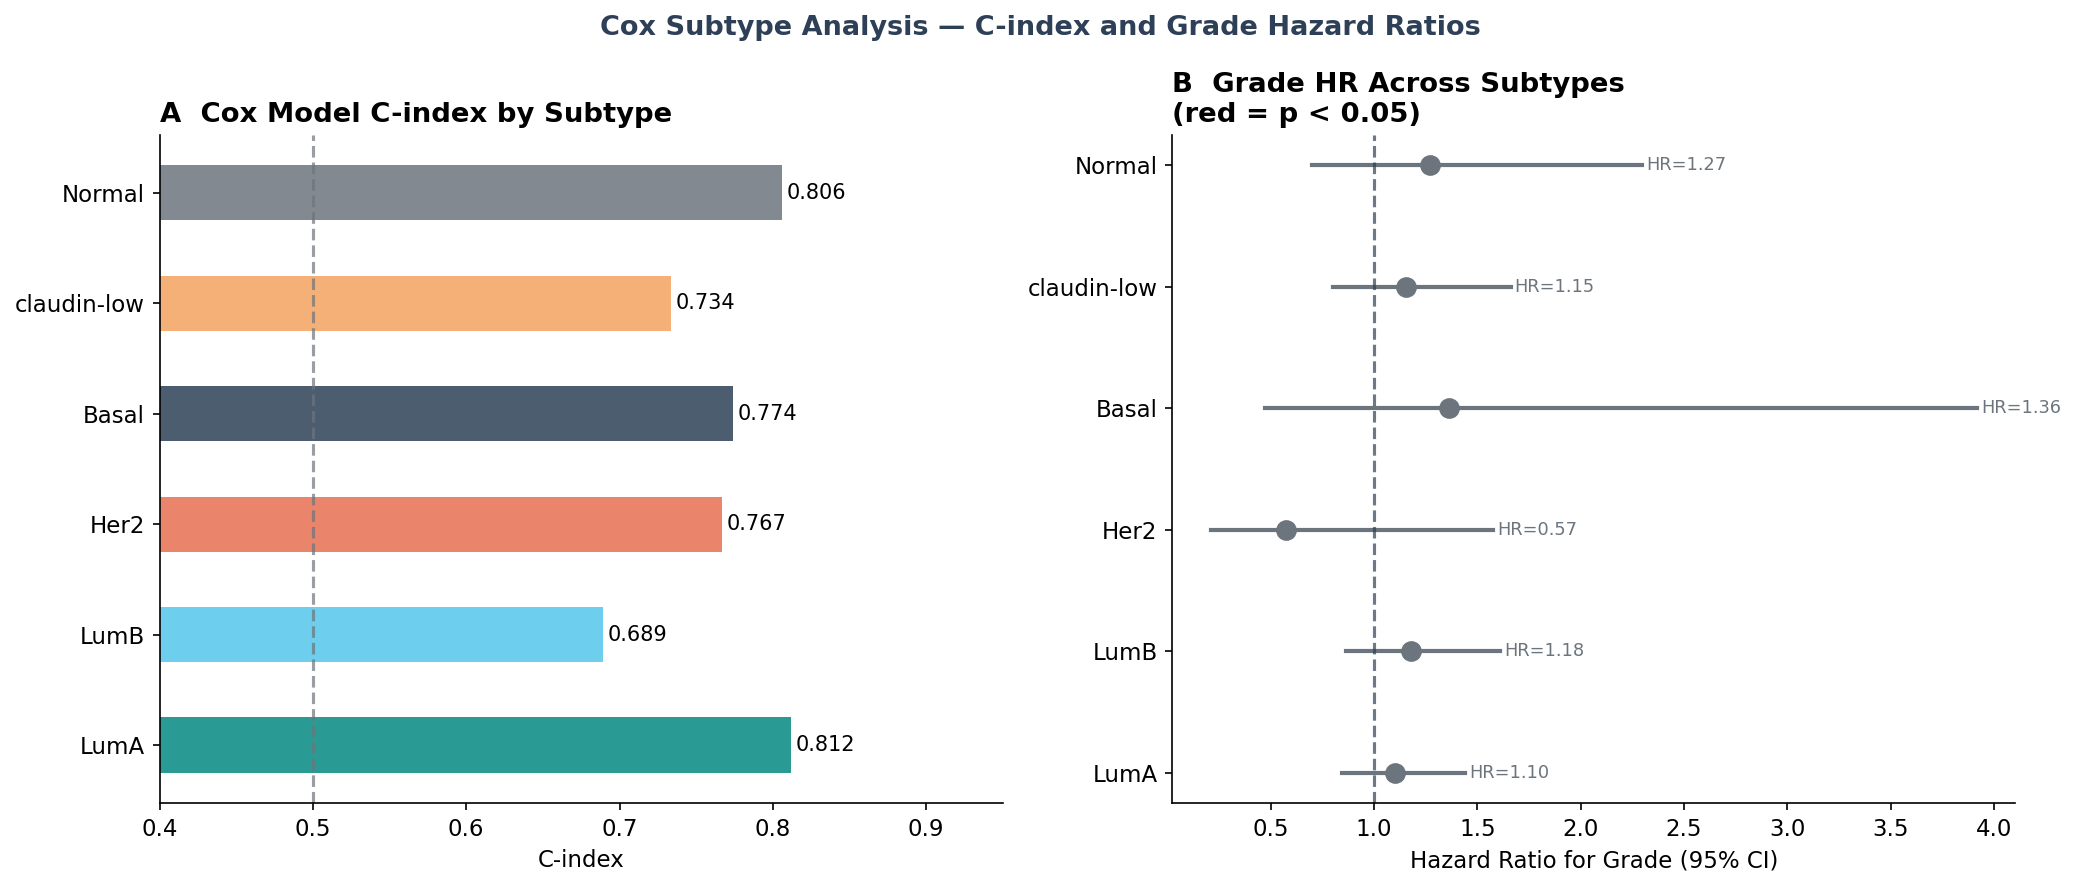

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("white")

subtypes_fitted = list(cox_results.keys())

# Panel A — C-index by subtype
ax0 = axes[0]
c_indices  = [cox_results[s].concordance_index_ for s in subtypes_fitted]
colors_bar = [SUBTYPE_COLORS[s] for s in subtypes_fitted]

bars = ax0.barh(subtypes_fitted, c_indices, color=colors_bar, alpha=0.85, height=0.5)
ax0.axvline(0.5, color=COLORS["gray"], ls="--", lw=1.5, alpha=0.7)
for bar, val in zip(bars, c_indices):
    ax0.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=10)
ax0.set_xlim(0.4, 0.95)
ax0.set_xlabel("C-index")
ax0.set_title("A  Cox Model C-index by Subtype", fontweight="bold", loc="left")

# Panel B — HR for grade (most variable feature) across subtypes
ax1 = axes[1]
y_pos = range(len(subtypes_fitted))

for i, subtype in enumerate(subtypes_fitted):
    cph_s = cox_results[subtype]
    if best_feat not in cph_s.summary.index:
        continue
    row   = cph_s.summary.loc[best_feat]
    color = COLORS["warm"] if row["p"] < 0.05 else COLORS["gray"]
    ax1.scatter(row["exp(coef)"], i, color=color, s=80, zorder=3)
    ax1.plot([row["exp(coef) lower 95%"], row["exp(coef) upper 95%"]], [i, i],
             color=color, lw=2, zorder=2)
    ax1.text(row["exp(coef) upper 95%"] + 0.02, i,
             f"HR={row['exp(coef)']:.2f}", va="center", fontsize=8.5,
             color=color)

ax1.axvline(1.0, color=COLORS["primary"], ls="--", lw=1.5, alpha=0.7)
ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(subtypes_fitted)
ax1.set_xlabel(f"Hazard Ratio for {feature_labels[best_feat]} (95% CI)")
ax1.set_title(f"B  {feature_labels[best_feat]} HR Across Subtypes\n(red = p < 0.05)",
              fontweight="bold", loc="left")

fig.suptitle("Cox Subtype Analysis — C-index and Grade Hazard Ratios",
             fontsize=13, fontweight="bold", color=COLORS["primary"])

plt.tight_layout()
plt.savefig("../notebooks/figures/fig9_subtype_cox.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings — Cox Subtype Analysis

**C-index (Panel A):**
- **LumA (0.812) and Normal (0.806)** have the best model fit — clinical 
  variables predict survival well in these subtypes
- **LumB (0.689)** has the lowest C-index — suggesting unmeasured factors 
  (molecular, genomic) drive prognosis in this subtype beyond what clinical 
  variables capture
- All subtypes well above 0.5 despite small sample sizes

**Grade HR across subtypes (Panel B):**
- **Grade is not statistically significant in any subtype** (all gray, p > 0.05) — 
  despite being significant in the full cohort Cox model (notebook 01)
- This is a classic example of **Simpson's paradox** — a variable can be 
  significant in the full population but lose significance within subgroups, 
  either due to reduced sample size or because subtype already captures the 
  grade effect
- **HER2 shows HR=0.57 for grade** — suggesting higher grade may be associated 
  with better survival in HER2+ patients, possibly reflecting that high-grade 
  HER2+ tumors respond better to targeted therapy. However, n=36 makes this 
  highly uncertain — wide CI confirms unreliable estimate
- **Basal shows HR=1.36 but with very wide CI** — consistent with high 
  biological heterogeneity within triple-negative breast cancer